In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

In [2]:
ruta_carpeta = Path(
    "../03_Tabla_de_metricas_por_mes_por_cuenca"
)

ruta_salida = Path(
    "../04_Resultados_estacionales_por_cuenca"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo es en donde se deve seleccionar una cuenca y un ledtime a seren graficados (se pueden elegir más que un leadtime, en este caso los resultados van a promediar entre los resutlados de cada lead).

In [7]:
lead_times_evaluar = [1]
cuenca = 11

df = pd.read_csv(f"{ruta_carpeta}/{cuenca}_df_esp_con_historico_crpss_bootstrap.csv")


In [8]:
# filtrar lead times
df_plot = df[df["lead"].isin(lead_times_evaluar)].copy()

cols = ["crpss", "crpss_med", "p5", "p25", "p75", "p95"]
df_plot[cols] = df_plot[cols] * 100
#print(df_plot.head())

#promediar por lead times
df_plot = (
    df_plot
    .groupby("mes")
    .agg({
        "crpss": "mean",
        "crpss_med": "mean",
        "p5": "mean",
        "p25": "mean",
        "p75": "mean",
        "p95": "mean"
    })
    .reset_index()
    .sort_values("mes")
)


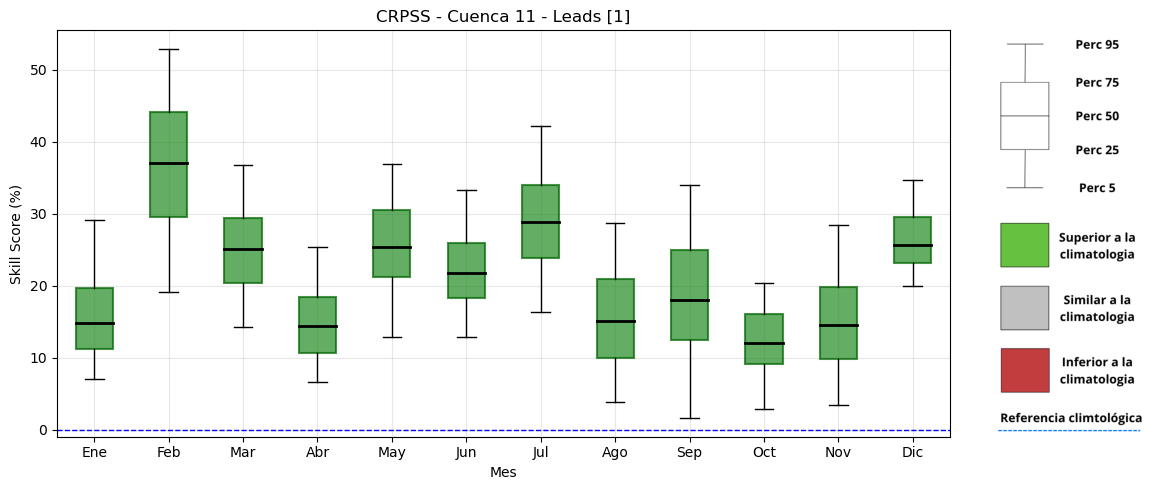

In [9]:
stats = []

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for _, row in df_plot.iterrows():
    stats.append({
        "label": meses[int(row["mes"]) - 1],
        "med": row["crpss_med"],
        "q1": row["p25"],
        "q3": row["p75"],
        "whislo": row["p5"],
        "whishi": row["p95"],
        "fliers": []
    })
    
# === gráfico ===

# cargar imagen
img = mpimg.imread("../legenda_lateral.png")

# figura con dos columnas
fig, (ax, ax_img) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [4, 1]}
)

# patch_artist=True permite colorear las cajas
boxplot = ax.bxp(
    stats,
    showfliers=False,
    patch_artist=True
)



tol = 5

for box, median_line, mediana in zip(
        boxplot["boxes"],
        boxplot["medians"],
        df_plot["crpss_med"]):

    if mediana > tol:
        color = "forestgreen"
        edge = "darkgreen"

    elif mediana < -tol:
        color = "firebrick"
        edge = "darkred"

    else:
        color = "lightgray"
        edge = "gray"

    # color de la caja
    box.set(
        facecolor=color,
        edgecolor=edge,
        alpha=0.7,
        linewidth=1.5
    )

    # color de la línea de la mediana
    median_line.set(
        color="black",
        linewidth=2
    )


#line al 0
ax.axhline(
    y=0,
    color="blue",
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Mes")
ax.set_ylabel("Skill Score (%)")

ax.set_title(
    f"CRPSS - Cuenca {cuenca} - Leads {lead_times_evaluar}"
)

ax.grid(True, alpha=0.3)

ax_img.imshow(img)
ax_img.axis("off")

plt.tight_layout()

# guardar
plt.savefig(ruta_salida / f"crpss_mensual_cuenca_{cuenca}_lead_{lead_times_evaluar}.png", dpi=300)

plt.show()